In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.insert(0,'/content/drive/MyDrive/thesis_utils')
!ls /content/drive/MyDrive/thesis_utils

 background_images	  fixhm_test_data	     HF_heatmap_center_numpy
 blink_data		  fixhm_train_data	    'Images for presentation'
 center_heatmap_viz.png   Gaze_test_data	     __pycache__
 CNN_Thesis.ipynb	  Gaze_train_data	     Raw_gaze_data
 Eye_ball_image		  Heatmap_feature_plot.py    raw_test_data
 Eyetracking		  heatmaps		     test2_video_frame.mp4
'file_methods (1).py'	  Heatmaps		     test_data
 file_methods.py	  helper_funcs.py	     test_heatmaps
 fixation_test_data	  HF_blink_data		     test_video_frame.mp4
 fixation_train_data	  HF_heatmap_center2_numpy   world_timestamps.npy



Held-out user: user1

Model: LR


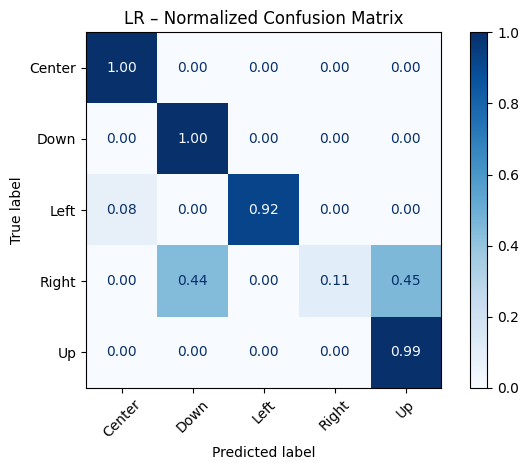


Model: DT


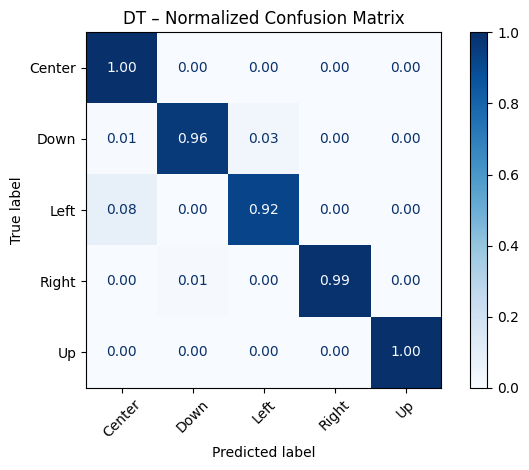


Model: RF


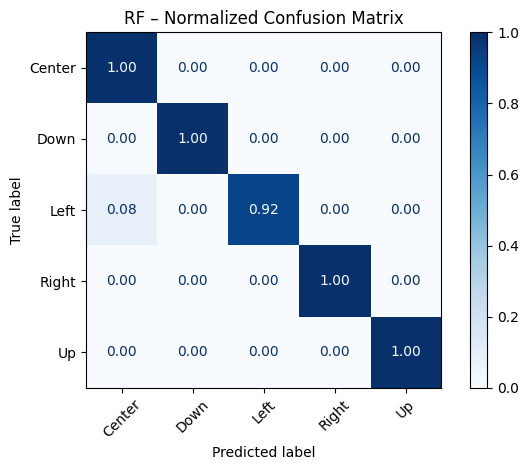


Model: GBDT


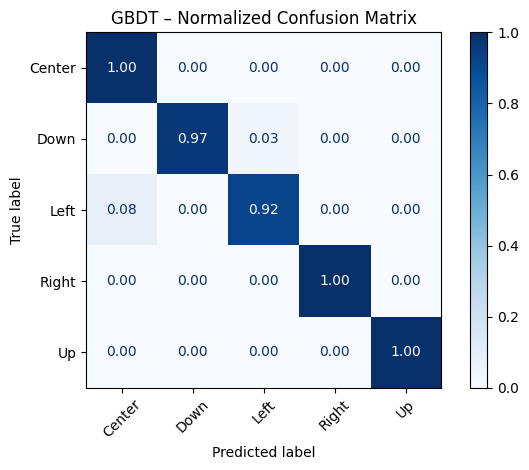


Held-out user: user2

Model: LR


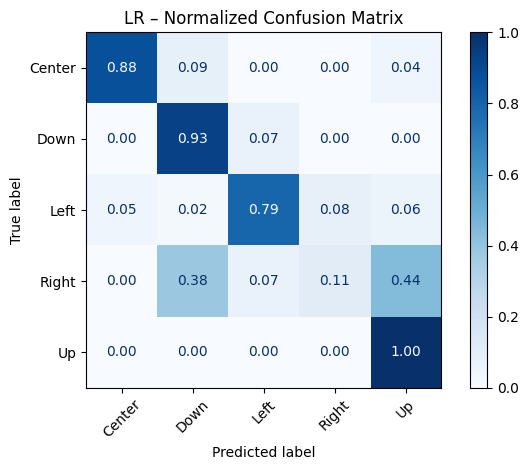


Model: DT


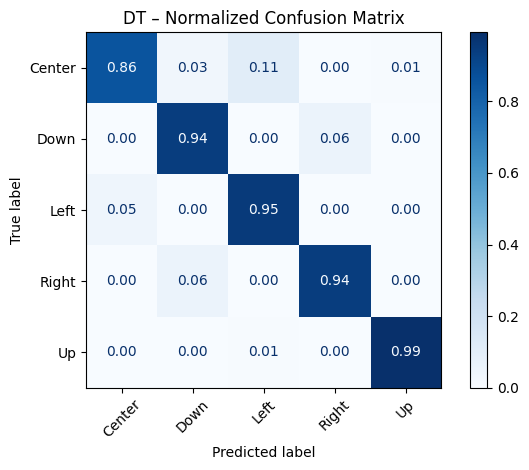


Model: RF


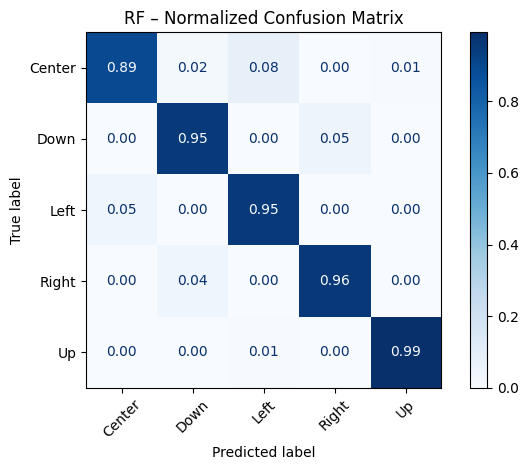


Model: GBDT


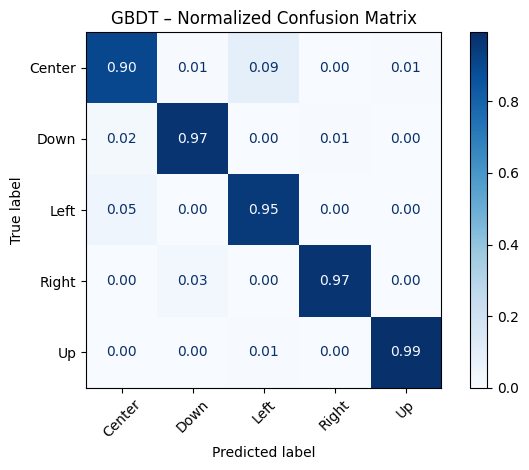


Held-out user: user3

Model: LR


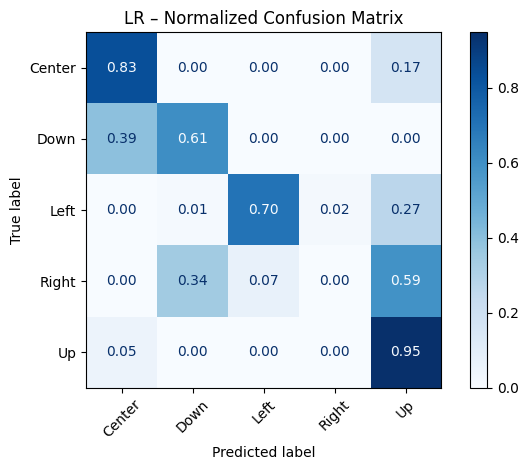


Model: DT


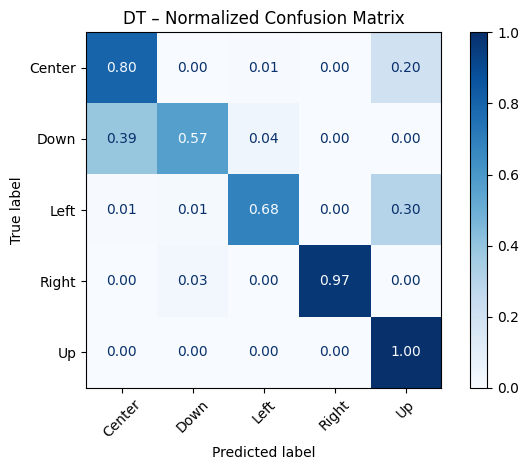


Model: RF


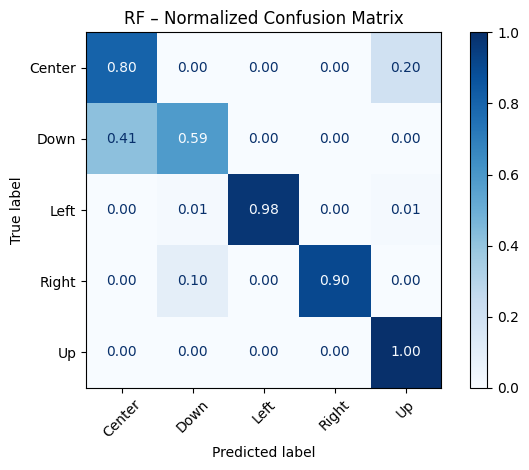


Model: GBDT


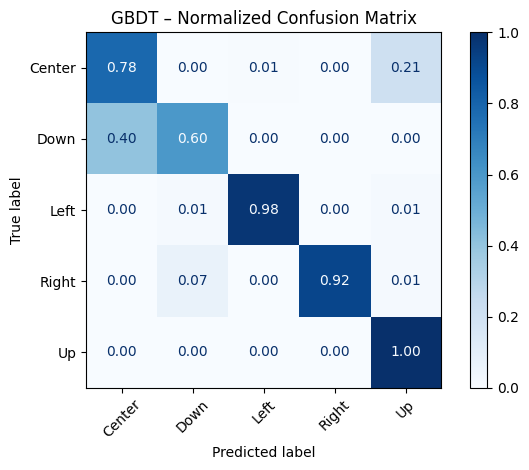


Held-out user: user4

Model: LR


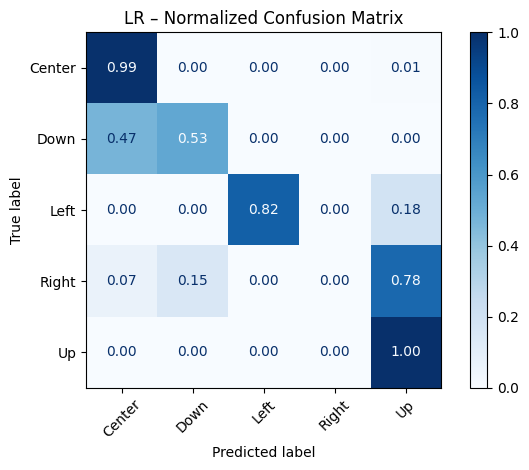


Model: DT


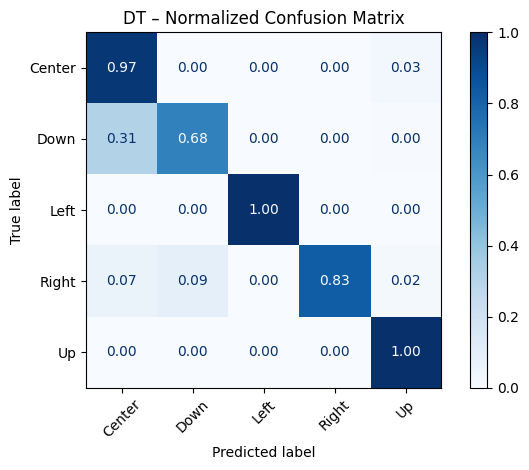


Model: RF


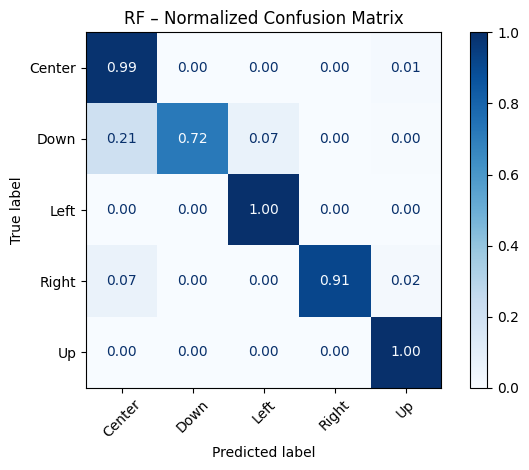


Model: GBDT


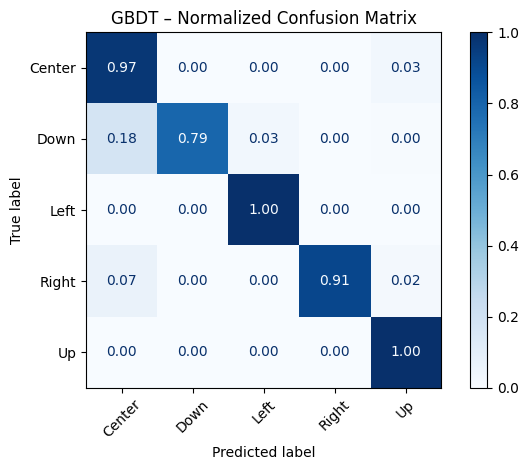


Held-out user: user5

Model: LR


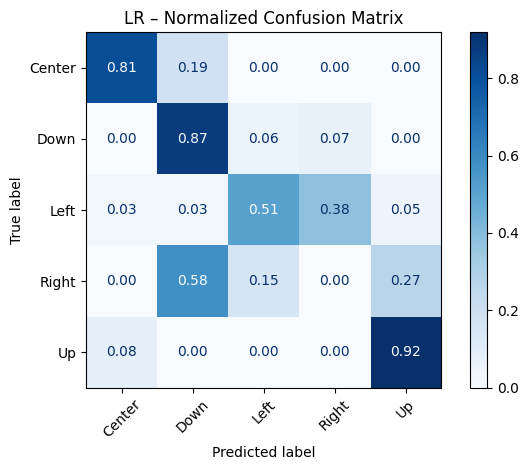


Model: DT


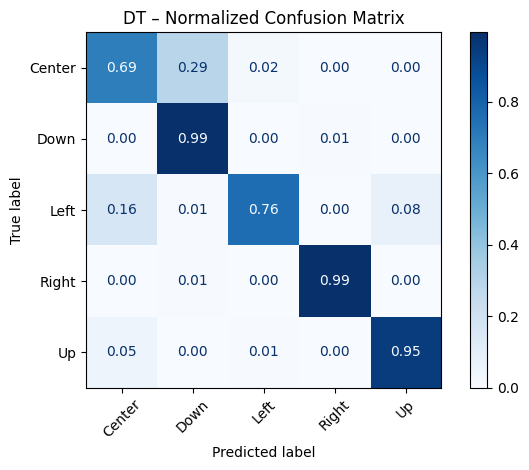


Model: RF


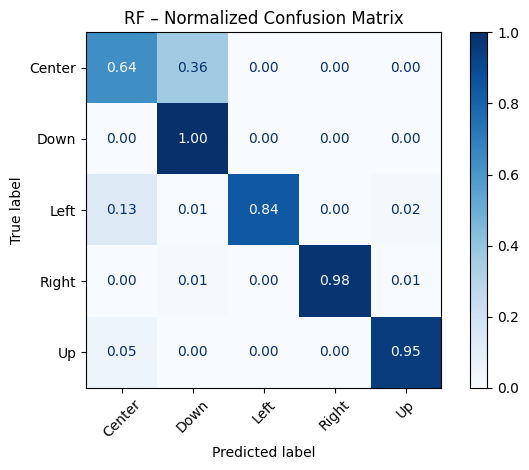


Model: GBDT


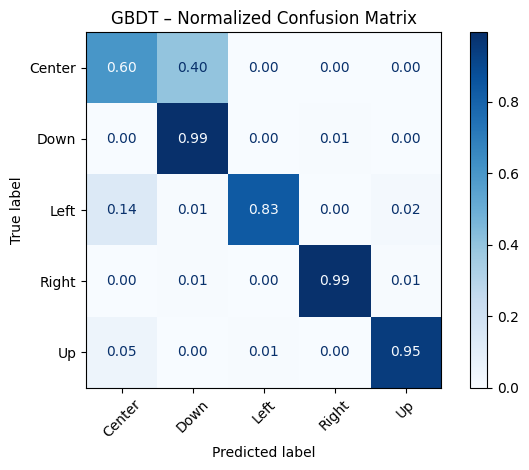


Per-fold metrics:
   HeldOutUser Model  Accuracy  Macro_Precision  Macro_Recall  Macro_F1
0        user1    LR  0.854478         0.900994      0.803892  0.774499
1        user1    DT  0.982587         0.978549      0.973922  0.976059
2        user1    RF  0.990050         0.990277      0.983156  0.986406
3        user1  GBDT  0.983831         0.978793      0.976212  0.977367
4        user2    LR  0.821343         0.770082      0.742427  0.728104
5        user2    DT  0.944844         0.934707      0.936206  0.934693
6        user2    RF  0.956835         0.948727      0.950803  0.949456
7        user2  GBDT  0.962830         0.959371      0.958173  0.958576
8        user3    LR  0.738845         0.608251      0.617706  0.603583
9        user3    DT  0.835958         0.883028      0.803658  0.826998
10       user3    RF  0.896325         0.900890      0.853985  0.870735
11       user3  GBDT  0.895013         0.903492      0.854397  0.871905
12       user4    LR  0.788438         0.6662

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# -----------------------
# CONFIG
BASE_DIR = "/content/drive/MyDrive/thesis_utils"
TRAIN_DIR = os.path.join(BASE_DIR, "fixation_train_data")
TEST_DIR  = os.path.join(BASE_DIR, "fixation_test_data")

USERS = ["user1", "user2", "user3", "user4", "user5"]

FEAT_COLS = ["Radial", "Angle"]
LABEL_COL = "Direction"
RANDOM_STATE = 42


# -----------------------
def load_csv(path):
    df = pd.read_csv(path)
    return df[FEAT_COLS + [LABEL_COL]].dropna()


def get_all_labels():
    labels = set()
    for u in USERS:
        labels.update(load_csv(f"{TRAIN_DIR}/{u}_train.csv")[LABEL_COL].unique())
        labels.update(load_csv(f"{TEST_DIR}/{u}_test.csv")[LABEL_COL].unique())
    return sorted(labels)


# -----------------------
def grid_search(X, y):
    models = {
        "LR": (LogisticRegression(max_iter=2000),
               {"clf__C":[0.1,1,10], "clf__solver":["lbfgs"]}),
        "DT": (DecisionTreeClassifier(random_state=RANDOM_STATE),
               {"clf__max_depth":[None,5,10]}),
        "RF": (RandomForestClassifier(random_state=RANDOM_STATE),
               {"clf__n_estimators":[200,500]}),
        "GBDT": (GradientBoostingClassifier(random_state=RANDOM_STATE),
                 {"clf__n_estimators":[100,200]})
    }

    best_params = {}

    for name,(clf,params) in models.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])
        gs = GridSearchCV(pipe, params, cv=3, scoring="accuracy", n_jobs=-1)
        gs.fit(X,y)
        best_params[name] = gs.best_params_

    return best_params


# -----------------------
def train_loop(X_train, y_train, X_test, y_test, best_params, labels):
    models = {
        "LR": LogisticRegression(max_iter=2000),
        "DT": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RF": RandomForestClassifier(random_state=RANDOM_STATE),
        "GBDT": GradientBoostingClassifier(random_state=RANDOM_STATE)
    }

    results = []

    for name,clf in models.items():
        print(f"\nModel: {name}")

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", clf)
        ]).set_params(**best_params[name])

        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)

        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        results.append({
            "Model": name,
            "Accuracy": report["accuracy"],
            "Macro_Precision": report["macro avg"]["precision"],
            "Macro_Recall": report["macro avg"]["recall"],
            "Macro_F1": report["macro avg"]["f1-score"]
        })

        cm = confusion_matrix(y_test, preds, labels=labels)
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        disp = ConfusionMatrixDisplay(cm, display_labels=labels)
        disp.plot(values_format=".2f", cmap=plt.cm.Blues)
        plt.title(f"{name} – Normalized Confusion Matrix")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


    return pd.DataFrame(results)


# -----------------------
# MAIN LOUO LOOP
all_labels = get_all_labels()
all_folds = []

for held_user in USERS:
    print("\n========================================")
    print(f"Held-out user: {held_user}")
    print("========================================")

    train_dfs = []
    for u in USERS:
        if u != held_user:
            train_dfs.append(load_csv(f"{TRAIN_DIR}/{u}_train.csv"))

    train_df = pd.concat(train_dfs, ignore_index=True)
    test_df  = load_csv(f"{TEST_DIR}/{held_user}_test.csv")

    X = train_df[FEAT_COLS]
    y = train_df[LABEL_COL]

    X_train, _, y_train, _ = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    X_test = test_df[FEAT_COLS]
    y_test = test_df[LABEL_COL]

    best_params = grid_search(X_train, y_train)
    fold_df = train_loop(X_train, y_train, X_test, y_test, best_params, all_labels)
    fold_df.insert(0, "HeldOutUser", held_user)

    all_folds.append(fold_df)


# -----------------------
# FINAL TABLES
results = pd.concat(all_folds, ignore_index=True)
print("\nPer-fold metrics:")
print(results)

summary = results.groupby("Model")[["Accuracy","Macro_Precision","Macro_Recall","Macro_F1"]] \
                 .agg(["mean","std"])

print("\nFinal cross-user summary (mean ± std):")
print(summary)
